In [1]:
# ============================================================
# Cell 0 - Import Packages and Load BTMS Model
# ============================================================

import os
import sys
import io
import re
import contextlib
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

PROJECT_ROOT = os.path.abspath("../..")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import lib.BTMS_model as BTMS_model

# Always reload the latest BTMS_model.py.
BTMS_model = importlib.reload(BTMS_model)

print(f'Project root: {PROJECT_ROOT}')
print(f'BTMS_model loaded from: {BTMS_model.__file__}')


Project root: d:\eBATS
BTMS_model loaded from: d:\eBATS\lib\BTMS_model.py


In [2]:
# ============================================================
# Cell 1 - Result-File Naming Configuration
# ============================================================

# [RESULTID]_[SCN]_[BTMS]_[MODEL]_[TASK].[ext]
# This notebook evaluates the final LC-PARK design selected from C0003R03.

CASE_ID = 'C0009'
REVISION = 'R01'
RESULT_ID = f'{CASE_ID}{REVISION}'

SCENARIO_CODE = 'PARK25'
BTMS_CODE = 'LC'
MODEL_CODE = '1D'
TASK_CODE = 'EVAL'

RESULT_BASENAME = f'{RESULT_ID}_{SCENARIO_CODE}_{BTMS_CODE}_{MODEL_CODE}_{TASK_CODE}'
NOTEBOOK_NAME = f'{RESULT_BASENAME}.ipynb'
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'out', CASE_ID)
os.makedirs(OUTPUT_DIR, exist_ok=True)

RESULT_FIGURE_NAME = f'{RESULT_BASENAME}_CFD_COMPARE.png'

# CFD comparison data for C0009.
# Put the following Fluent report files in:
#   data/C0009/max-rfile.out
#   data/C0009/min-rfile.out
ENABLE_CFD_COMPARISON = True

CFD_DATA_DIR = os.path.join(
    PROJECT_ROOT,
    'data',
    CASE_ID,
)

CFD_FILES = {
    'CFD_max': 'max-rfile.out',
    'CFD_min': 'min-rfile.out',
}

print(f'Result basename: {RESULT_BASENAME}')
print(f'Notebook file: {NOTEBOOK_NAME}')
print(f'CFD data directory: {CFD_DATA_DIR}')
print(f'CFD comparison enabled: {ENABLE_CFD_COMPARISON}')


Result basename: C0009R01_PARK25_LC_1D_EVAL
Notebook file: C0009R01_PARK25_LC_1D_EVAL.ipynb
CFD data directory: d:\eBATS\data\C0009
CFD comparison enabled: True


In [3]:
# ============================================================
# Cell 2 - Load Battery Heat-Generation Data
# ============================================================

SIM_DURATION_S = 1920.0   # s, physical mission duration
dt = 1.0                  # s, integration time step

NUM_STEPS = int(round(SIM_DURATION_S / dt))
if not np.isclose(NUM_STEPS * dt, SIM_DURATION_S):
    raise ValueError('SIM_DURATION_S must be an integer multiple of dt.')

# Keep the original downstream variable name.
SIM_TIME_S = NUM_STEPS

file_name = os.path.join(
    PROJECT_ROOT,
    'data',
    'MD05E070207A1  data_power gen_single cell_Liu_20260421.xlsx',
)

if not os.path.isfile(file_name):
    raise FileNotFoundError(
        f'Heat-generation data file not found: {file_name}\n'
        'Place the Excel file in the project data folder.'
    )

df = pd.read_excel(file_name, sheet_name='Sheet1')
power_generation_data_1s = df['Qbat(W)'].dropna().to_numpy(dtype=float)

# Source Qbat data are 1-s samples.
time_s = np.arange(SIM_TIME_S + 1) * dt
power_indices = np.floor(time_s[:-1]).astype(int)
power_indices = np.clip(power_indices, 0, len(power_generation_data_1s) - 1)
power_generation_data = power_generation_data_1s[power_indices]

print(f'Simulation duration: {SIM_DURATION_S:.1f} s')
print(f'Time step dt: {dt:.3f} s')
print(f'Number of numerical steps: {SIM_TIME_S}')
print(f'Q_gen array length: {len(power_generation_data)}')


Simulation duration: 1920.0 s
Time step dt: 1.000 s
Number of numerical steps: 1920
Q_gen array length: 1920


In [4]:
# ============================================================
# Cell 3 - Model Settings and Final Selected LC-PARK Design
# ============================================================

BATTERY_PROPS = {
    'm_bat': 48e-3,          # kg
    'cp_bat': 830.0,         # J/(kg K)
    'D_bat': 18e-3,          # m
    'H_bat': 65e-3,          # m
}

MODULE_LAYOUT = {
    'N_r': 20,               # control volumes along coolant-flow direction
    'N_c': 16,               # battery columns in transverse direction
}

# Final design selected from the two-stage C0003R03 scan:
# T_water = 25 degC, m_dot_total = 0.045 kg/s, N_ch = 32,
# W_channel = 10 mm, H_channel = 3 mm, L_channel = 380 mm.
LIQUID_SETTINGS = {
    'fluid': 'Water',
    'p_water': 101325.0,

    'W_channel': 10.0e-3,     # m
    'H_channel': 3.0e-3,      # m
    'L_channel': 0.380,       # m

    # Same transverse geometry logic as C0003R03.
    'W_battery': 16 * 18.0e-3,  # 288 mm battery-array width
    'S_min': 1.0e-3,             # minimum channel spacing = 1 mm

    # Conduction distance from battery-side plate surface to coolant.
    'delta_plate_coolant': 2.0e-3,

    'k_plate': 200.0,         # W/(m K)
    'rho_plate': 2719.0,      # kg/m3

    'pump_efficiency': 0.35,
    'K_minor': 0.0,
    'm_pump': 0.0,            # kg
    'm_pipe': 0.0,            # kg
}

SELECTED_CONDITION = {
    'case_id': f'{CASE_ID}_S001',
    'T_water': 25.0,                  # degC
    'm_dot_total': 0.045,             # kg/s, complete cooling system
    'num_parallel_channels': 32,
}

SOLVER_SETTINGS = {
    'solver_tol': 1e-6,
    'solver_maxiter': 1000,
}

mission_stages = [
    ('takeoff',       0.0,    6.0),
    ('climb',         6.0,   36.0),
    ('transition1',  36.0,  180.0),
    ('cruise',      180.0, 1560.0),
    ('transition2',1560.0, 1704.0),
    ('descent',    1704.0, 1734.0),
    ('hover',      1734.0, 1914.0),
    ('landing',    1914.0, 1920.0),
]

# Map configuration values to downstream variables.
m_bat = BATTERY_PROPS['m_bat']
cp_bat = BATTERY_PROPS['cp_bat']
D_bat = BATTERY_PROPS['D_bat']
H_bat = BATTERY_PROPS['H_bat']
A_battery = np.pi * D_bat * H_bat

N_r = MODULE_LAYOUT['N_r']
N_c = MODULE_LAYOUT['N_c']
num_seg = N_r

fluid = LIQUID_SETTINGS['fluid']
p_water = LIQUID_SETTINGS['p_water']

W_channel = LIQUID_SETTINGS['W_channel']
H_channel = LIQUID_SETTINGS['H_channel']
L_channel = LIQUID_SETTINGS['L_channel']
W_battery = LIQUID_SETTINGS['W_battery']
S_min = LIQUID_SETTINGS['S_min']
delta_plate_coolant = LIQUID_SETTINGS['delta_plate_coolant']
k_plate = LIQUID_SETTINGS['k_plate']
rho_plate = LIQUID_SETTINGS['rho_plate']
pump_efficiency = LIQUID_SETTINGS['pump_efficiency']
K_minor = LIQUID_SETTINGS['K_minor']
m_pump = LIQUID_SETTINGS['m_pump']
m_pipe = LIQUID_SETTINGS['m_pipe']

pump_operation_time = SIM_DURATION_S
solver_tol = SOLVER_SETTINGS['solver_tol']
solver_maxiter = SOLVER_SETTINGS['solver_maxiter']

# The thermal solver represents one parallel cooling channel.
SELECTED_CONDITION['num_cell_seg'] = (
    N_c / SELECTED_CONDITION['num_parallel_channels']
)

# Derived geometry using the same logic as C0003R03.
num_parallel_channels_selected = SELECTED_CONDITION['num_parallel_channels']
num_spacing_intervals_selected = num_parallel_channels_selected + 1
W_plate_spacing_limit_selected = (
    num_parallel_channels_selected * W_channel
    + num_spacing_intervals_selected * S_min
)
W_plate_selected = max(W_battery, W_plate_spacing_limit_selected)
S_channel_selected = (
    W_plate_selected - num_parallel_channels_selected * W_channel
) / num_spacing_intervals_selected
H_plate_selected = H_channel + delta_plate_coolant
Dh_selected = 2.0 * W_channel * H_channel / (W_channel + H_channel)

print('Final selected LC-PARK condition:')
print(f"  T_water = {SELECTED_CONDITION['T_water']:.1f} degC")
print(f"  m_dot_total = {SELECTED_CONDITION['m_dot_total']:.3f} kg/s")
print(f"  N_ch = {SELECTED_CONDITION['num_parallel_channels']}")
print(f"  num_cell_seg = {SELECTED_CONDITION['num_cell_seg']:.4f}")
print()
print('Final selected cold-plate geometry:')
print(f'  W_channel = {W_channel * 1e3:.2f} mm')
print(f'  H_channel = {H_channel * 1e3:.2f} mm')
print(f'  L_channel = {L_channel * 1e3:.2f} mm')
print(f'  Dh = {Dh_selected * 1e3:.3f} mm')
print(f'  W_plate = {W_plate_selected * 1e3:.2f} mm')
print(f'  S_channel = {S_channel_selected * 1e3:.2f} mm')
print(f'  delta_plate_coolant = {delta_plate_coolant * 1e3:.2f} mm')
print(f'  H_plate = {H_plate_selected * 1e3:.2f} mm')


Final selected LC-PARK condition:
  T_water = 25.0 degC
  m_dot_total = 0.045 kg/s
  N_ch = 32
  num_cell_seg = 0.5000

Final selected cold-plate geometry:
  W_channel = 10.00 mm
  H_channel = 3.00 mm
  L_channel = 380.00 mm
  Dh = 4.615 mm
  W_plate = 353.00 mm
  S_channel = 1.00 mm
  delta_plate_coolant = 2.00 mm
  H_plate = 5.00 mm


In [5]:
# ============================================================
# Cell 4 - Build the Selected Single Case
# ============================================================

single_case = {
    'case_id': SELECTED_CONDITION['case_id'],
    'T_water': float(SELECTED_CONDITION['T_water']),
    'm_dot_total': float(SELECTED_CONDITION['m_dot_total']),
    'num_cell_seg': float(SELECTED_CONDITION['num_cell_seg']),
}

print('Selected single case:')
print(single_case)


Selected single case:
{'case_id': 'C0009_S001', 'T_water': 25.0, 'm_dot_total': 0.045, 'num_cell_seg': 0.5}


In [6]:
# ============================================================
# Cell 5 - Calculate Water Properties at Selected Inlet Temperature
# ============================================================

T_water = float(single_case['T_water'])
T_water_K = T_water + 273.15

mu_water = CP.PropsSI('V', 'T', T_water_K, 'P', p_water, fluid)
rho_water = CP.PropsSI('D', 'T', T_water_K, 'P', p_water, fluid)
cp_water = CP.PropsSI('C', 'T', T_water_K, 'P', p_water, fluid)
k_water = CP.PropsSI('L', 'T', T_water_K, 'P', p_water, fluid)
Pr_water = cp_water * mu_water / k_water

water_props_cache = {
    float(T_water): {
        'mu_water': mu_water,
        'rho_water': rho_water,
        'cp_water': cp_water,
        'k_water': k_water,
        'Pr_water': Pr_water,
    }
}

print(f'Water properties calculated at T_water = {T_water:.1f} degC.')


Water properties calculated at T_water = 25.0 degC.


In [7]:
# ============================================================
# Cell 6 - Run the Selected Single Case
# Latest calculation logic aligned with C0003R03
# ============================================================

def run_one_case(case_id, T_water, m_dot_total, num_cell_seg):
    water_props = water_props_cache[float(T_water)]

    if m_dot_total <= 0:
        raise ValueError('m_dot_total must be positive.')
    if num_cell_seg <= 0:
        raise ValueError('num_cell_seg must be positive.')

    # ---------------------------------------------------------
    # Number of parallel channels and per-channel mass flow rate
    # ---------------------------------------------------------
    num_parallel_channels_float = N_c / num_cell_seg
    num_parallel_channels = int(round(num_parallel_channels_float))

    if not np.isclose(num_parallel_channels, num_parallel_channels_float):
        raise ValueError(
            f'num_cell_seg={num_cell_seg} does not produce '
            'an integer channel count.'
        )

    # ---------------------------------------------------------
    # Cold-plate transverse geometry: same as C0003R03
    # ---------------------------------------------------------
    num_spacing_intervals = num_parallel_channels + 1
    W_plate_spacing_limit = (
        num_parallel_channels * W_channel
        + num_spacing_intervals * S_min
    )
    W_plate = max(W_battery, W_plate_spacing_limit)
    S_channel_case = (
        W_plate - num_parallel_channels * W_channel
    ) / num_spacing_intervals

    tol = 1e-12
    if W_plate < W_battery - tol:
        raise RuntimeError(
            'Cold-plate width is smaller than the battery-array width.'
        )
    if S_channel_case < S_min - tol:
        raise RuntimeError(
            'Calculated channel spacing is below the minimum 1 mm.'
        )

    # Total flow is divided equally among parallel channels.
    m_dot_channel = m_dot_total / num_parallel_channels

    # ---------------------------------------------------------
    # Rectangular-channel geometry and heat transfer
    # ---------------------------------------------------------
    A_cool_cs = W_channel * H_channel
    Dh = 2.0 * W_channel * H_channel / (W_channel + H_channel)
    A_HT_seg = (W_channel + 2.0 * H_channel) * L_channel / num_seg

    u_water = m_dot_channel / (water_props['rho_water'] * A_cool_cs)
    Re_water = (
        water_props['rho_water']
        * u_water
        * Dh
        / water_props['mu_water']
    )

    Nu_water = BTMS_model.liquid_nusselt_number_rect_channel(
        W_channel,
        H_channel,
    )
    h_water = Nu_water * water_props['k_water'] / Dh
    R_plate = delta_plate_coolant / k_plate
    htc_global = 1.0 / (1.0 / h_water + R_plate)
    htc_cool = np.ones(num_seg) * htc_global

    # ---------------------------------------------------------
    # Pump power: pressure drop from one representative channel,
    # total pump power from the complete system mass flow rate.
    # ---------------------------------------------------------
    f_water = BTMS_model.cal_friction_factor_rect_channel(
        Re_water,
        W_channel,
        H_channel,
    )

    pump_args = {
        'fluid_cool': fluid,
        'rho_cool': water_props['rho_water'],
        'mu_cool': water_props['mu_water'],
        'A_cool_cs': A_cool_cs,
        'D_channel': Dh,
        'L_channel': L_channel,
        'm_dot_total': m_dot_total,
        'num_channel': num_parallel_channels,
        'pump_efficiency': pump_efficiency,
        'K_minor': K_minor,
        'operation_time': pump_operation_time,
    }

    pump_results = BTMS_model.cal_btms_aux_power(
        pump_args,
        friction_factor=f_water,
    )
    P_pump = float(pump_results['P_aux_W'])
    E_pump_cumulative = float(pump_results['E_aux_J'])

    if not np.isclose(
        pump_results['Re'],
        Re_water,
        rtol=1e-12,
        atol=0.0,
    ):
        raise RuntimeError(
            'Inconsistent Reynolds number in pump-power calculation.'
        )

    # ---------------------------------------------------------
    # Full liquid-cooling BTMS mass: same logic as C0003R03
    # ---------------------------------------------------------
    mass_args = {
        'fluid_cool': fluid,
        'rho_cool': water_props['rho_water'],
        'rho_plate': rho_plate,
        'L_channel': L_channel,
        'W_plate': W_plate,
        'A_cool_cs': A_cool_cs,
        'H_channel': H_channel,
        'H_bottom': delta_plate_coolant,
        'num_channel': num_parallel_channels,
        'm_pump': m_pump,
        'm_pipe': m_pipe,
        'return_components': True,
    }

    mass_results = BTMS_model.cal_btms_mass(mass_args)
    mtotal = float(mass_results['m_BTMS_kg'])

    mass_component_sum = (
        mass_results['m_plate_kg']
        + mass_results['m_coolant_kg']
        + mass_results['m_pump_kg']
        + mass_results['m_pipe_kg']
    )

    if not np.isclose(
        mtotal,
        mass_component_sum,
        rtol=1e-12,
        atol=1e-12,
    ):
        raise RuntimeError(
            'Inconsistent component sum in BTMS mass calculation.'
        )

    # Initial battery and coolant temperatures equal inlet temperature.
    T_bat = np.ones(num_seg) * T_water
    T_cool = np.ones(num_seg) * T_water

    T_bat_history = np.zeros((SIM_TIME_S + 1, num_seg))
    T_water_history = np.zeros((SIM_TIME_S + 1, num_seg))
    T_bat_history[0, :] = T_bat
    T_water_history[0, :] = T_cool

    # ---------------------------------------------------------
    # Full-mission transient solution
    # ---------------------------------------------------------
    for k in range(SIM_TIME_S):
        t = time_s[k]
        is_cool = True

        args = {
            'num_seg': num_seg,
            'num_seg_bat': num_seg,
            'dt': dt,
            'T_cool_pre': T_cool,
            'T_bat_pre': T_bat,
            'u_cool_in': u_water,
            'p_cool': p_water,
            'fluid_cool': fluid,
            'A_HT_seg': A_HT_seg,
            'A_cool_cs': A_cool_cs,
            'm_bat': m_bat,
            'cp_bat': cp_bat,
            'D_bat': D_bat,
            'T_cool_in': T_water,
            'T_cool_out': max(float(T_cool[-1]), T_water),
            'is_cool': is_cool,
            'htc_cool': htc_cool,
            'cp_cool': water_props['cp_water'],
            'rho_cool': water_props['rho_water'],
            'Q_gen': power_generation_data[k],
            'num_cell_seg': num_cell_seg,
            'debug': False,
        }

        try:
            with contextlib.redirect_stdout(io.StringIO()):
                T_dist = BTMS_model.solve_coolant_temperature_distribution(
                    args,
                    tol=solver_tol,
                    maxiter=solver_maxiter,
                    debug=False,
                )
        except Exception as e:
            print('\nSolver failed inside run_one_case.')
            print(f'case_id = {case_id}')
            print(f'm_dot_total = {m_dot_total} kg/s')
            print(f'm_dot_channel = {m_dot_channel} kg/s')
            print(f'num_parallel_channels = {num_parallel_channels}')
            print(f'T_water_in = {T_water} degC')
            print(f'W_plate = {W_plate * 1e3} mm')
            print(f'S_channel = {S_channel_case * 1e3} mm')
            print(f'Dh = {Dh * 1e3} mm')
            print(f'num_cell_seg = {num_cell_seg}')
            print(f'time step k = {k}')
            print(f't = {t:.1f} s')
            print(f'Q_gen = {power_generation_data[k]} W')
            print(f'u_water = {u_water}')
            print(f'Re_water = {Re_water}')
            print(f'Nu_water = {Nu_water}')
            print(f'h_water = {h_water}')
            print(f'htc_global = {htc_global}')
            print(f'A_HT_seg = {A_HT_seg}')
            print(f'A_cool_cs = {A_cool_cs}')
            print(f'P_pump = {P_pump}')
            print(f'E_pump_cumulative = {E_pump_cumulative}')
            print(f'mtotal = {mtotal}')
            print(
                'T_bat_min/max before solve = '
                f'{np.min(T_bat)}, {np.max(T_bat)}'
            )
            print(
                'T_cool_min/max before solve = '
                f'{np.min(T_cool)}, {np.max(T_cool)}'
            )
            print(f'solver_tol = {solver_tol}')
            print(f'solver_maxiter = {solver_maxiter}')
            print(f'error = {repr(e)}')
            raise

        if not np.all(np.isfinite(T_dist)):
            print('\nSolver returned non-finite values.')
            print(f'case_id = {case_id}')
            print(f'time step k = {k}')
            print(f't = {t:.1f} s')
            print(
                'T_dist_min/max = '
                f'{np.nanmin(T_dist)}, {np.nanmax(T_dist)}'
            )
            raise FloatingPointError('Non-finite values detected in T_dist')

        T_cool = T_dist[:num_seg]
        T_bat = T_dist[num_seg:]
        T_bat_history[k + 1, :] = T_bat
        T_water_history[k + 1, :] = T_cool

    # ---------------------------------------------------------
    # Mission indicators
    # ---------------------------------------------------------
    Tmax = np.max(T_bat_history, axis=1)
    Tmin = np.min(T_bat_history, axis=1)
    DeltaT = Tmax - Tmin
    Twater_out = T_water_history[:, -1]

    cruise_end_time = next(
        t1
        for stage_name, _, t1 in mission_stages
        if stage_name == 'cruise'
    )

    def idx(t_value):
        return int(round(t_value / dt))

    row = {
        'case_id': case_id,
        'T_water_in_C': float(T_water),
        'm_dot_total_kg_s': float(m_dot_total),
        'm_dot_channel_kg_s': float(m_dot_channel),
        'num_cell_seg': float(num_cell_seg),
        'num_parallel_channels': int(num_parallel_channels),
        'W_channel_mm': float(W_channel * 1e3),
        'H_channel_mm': float(H_channel * 1e3),
        'L_channel_mm': float(L_channel * 1e3),
        'W_plate_mm': float(W_plate * 1e3),
        'S_channel_mm': float(S_channel_case * 1e3),
        'H_plate_mm': float((H_channel + delta_plate_coolant) * 1e3),
        'Dh_mm': float(Dh * 1e3),
        'u_water_m_s': float(u_water),
        'Re_water': float(Re_water),
        'Nu_water': float(Nu_water),
        'h_water_W_m2K': float(h_water),
        'htc_global_W_m2K': float(htc_global),
        'P_pump': P_pump,
        'E_pump_cumulative': E_pump_cumulative,
        'm_plate_kg': float(mass_results['m_plate_kg']),
        'm_coolant_kg': float(mass_results['m_coolant_kg']),
        'mtotal': mtotal,
        'Tmax_mission_C': float(np.max(Tmax)),
        'DeltaT_mission_max_C': float(np.max(DeltaT)),
        'Twater_out_cruise_end_C': float(Twater_out[idx(cruise_end_time)]),
    }

    for stage_name, t0, t1 in mission_stages:
        row[f'dTmax_{stage_name}_C'] = float(
            Tmax[idx(t1)] - Tmax[idx(t0)]
        )

    histories = {
        'time_s': time_s.copy(),
        'Tmax_C': Tmax.copy(),
        'Tmin_C': Tmin.copy(),
        'DeltaT_C': DeltaT.copy(),
        'Twater_out_C': Twater_out.copy(),
        'T_bat_history_C': T_bat_history.copy(),
        'T_water_history_C': T_water_history.copy(),
    }

    return row, histories


Running final selected LC-PARK condition...
CFD_max: 1921 points, t = 0.0-1920.0 s, T = 25.000-37.001 degC
CFD_min: 1921 points, t = 0.0-1920.0 s, T = 25.000-34.152 degC


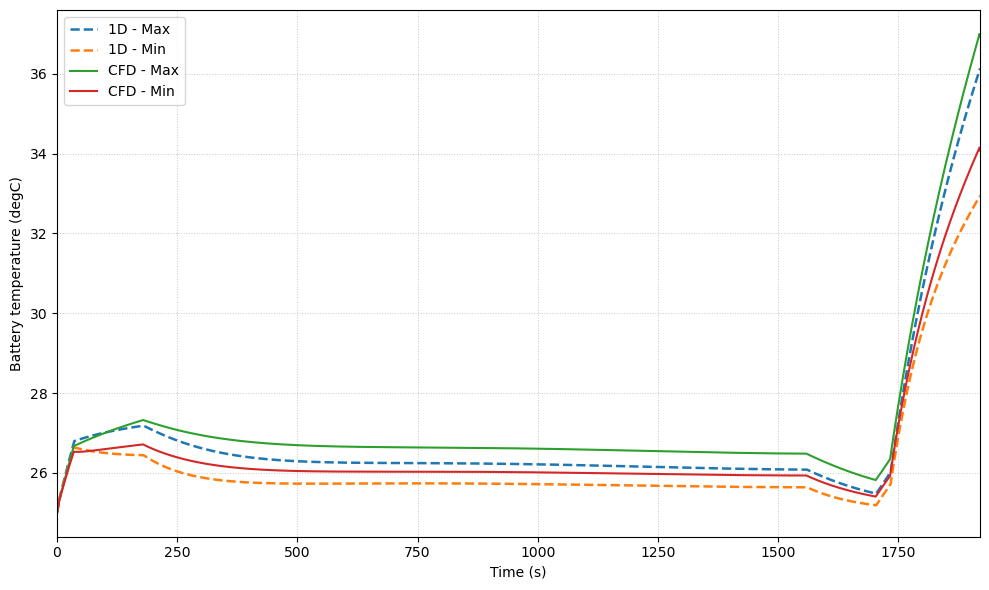


Final selected-condition geometry:
  N_ch = 32
  W_channel = 10.000 mm
  H_channel = 3.000 mm
  L_channel = 380.000 mm
  W_plate = 353.000 mm
  S_channel = 1.000 mm
  H_plate = 5.000 mm

Final selected-condition results:
  Tmax = 36.134 degC
  DeltaTmax = 3.189 degC
  m_dot_channel = 0.00140625 kg/s
  u_water = 0.04701 m/s
  Re = 243.08
  P_pump,total = 0.003372 W
  E_pump = 6.474 J
  m_plate = 0.83174 kg
  m_coolant = 0.36372 kg
  m_total = 1.19547 kg

CFD comparison data:
  max-rfile.out: peak = 37.001 degC
  min-rfile.out: peak = 34.152 degC

Saved comparison figure: d:\eBATS\out\C0009\C0009R01_PARK25_LC_1D_EVAL_CFD_COMPARE.png


In [8]:
# ============================================================
# Cell 7 - Run Final Selected Case and Plot 1D/CFD Comparison
# ============================================================

print('Running final selected LC-PARK condition...')
summary_row, histories = run_one_case(**single_case)

# ------------------------------------------------------------
# Read Fluent temperature-history report files from data/C0009
# ------------------------------------------------------------
def read_fluent_temperature_history(file_path):
    """
    Read a Fluent report-definition history file such as:

        "max-rfile"
        "Time Step" "max etc.."
        ("Time Step" "max" "flow-time")
        0 298.15 0
        1 298.21 1
        ...

    Returns
    -------
    time_s : ndarray
        Flow time in seconds.
    temperature_C : ndarray
        Temperature converted to degC when the source data are in K.
    """
    rows = []

    with open(file_path, 'r', encoding='utf-8', errors='ignore') as file:
        for line in file:
            tokens = re.sub(r'[(),]', ' ', line.strip()).split()

            try:
                values = [float(token) for token in tokens]
            except ValueError:
                continue

            # Fluent report files used here contain:
            # [time-step, temperature, flow-time].
            # Use flow-time as x and temperature as y.
            if len(values) >= 3:
                rows.append([values[-1], values[-2]])
            elif len(values) == 2:
                rows.append([values[0], values[1]])

    if not rows:
        raise ValueError(f'No numeric CFD history found in: {file_path}')

    data = np.asarray(rows, dtype=float)
    time_cfd = data[:, 0]
    temperature_cfd = data[:, 1]

    # Fluent temperature reports are normally written in K.
    if np.nanmedian(temperature_cfd) > 150.0:
        temperature_cfd = temperature_cfd - 273.15

    # Sort by flow time in case the report file is not ordered.
    order = np.argsort(time_cfd)
    time_cfd = time_cfd[order]
    temperature_cfd = temperature_cfd[order]

    return time_cfd, temperature_cfd


cfd_histories = {}
if ENABLE_CFD_COMPARISON:
    for line_name, file_name in CFD_FILES.items():
        file_path = os.path.join(CFD_DATA_DIR, file_name)

        if not os.path.isfile(file_path):
            raise FileNotFoundError(
                f'CFD comparison is enabled but file was not found: {file_path}\n'
                f'Please place {file_name} in data/{CASE_ID}/.'
            )

        cfd_histories[line_name] = read_fluent_temperature_history(file_path)

        time_cfd, temperature_cfd = cfd_histories[line_name]
        print(
            f'{line_name}: {len(time_cfd)} points, '
            f't = {time_cfd[0]:.1f}-{time_cfd[-1]:.1f} s, '
            f'T = {np.min(temperature_cfd):.3f}-{np.max(temperature_cfd):.3f} degC'
        )

# ------------------------------------------------------------
# Plot temperature histories: 1D vs CFD
# ------------------------------------------------------------
plt.rcdefaults()
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 6))

# 1D results
ax.plot(
    histories['time_s'],
    histories['Tmax_C'],
    linewidth=1.8,
    linestyle='--',
    label='1D - Max',
)
ax.plot(
    histories['time_s'],
    histories['Tmin_C'],
    linewidth=1.8,
    linestyle='--',
    label='1D - Min',
)

# CFD results from data/C0009/max-rfile.out and min-rfile.out
if ENABLE_CFD_COMPARISON:
    time_cfd_max, temperature_cfd_max = cfd_histories['CFD_max']
    ax.plot(
        time_cfd_max,
        temperature_cfd_max,
        linewidth=1.5,
        linestyle='-',
        label='CFD - Max',
    )

    time_cfd_min, temperature_cfd_min = cfd_histories['CFD_min']
    ax.plot(
        time_cfd_min,
        temperature_cfd_min,
        linewidth=1.5,
        linestyle='-',
        label='CFD - Min',
    )

ax.set_xlabel('Time (s)')
ax.set_ylabel('Battery temperature (degC)')
ax.set_xlim(0.0, SIM_DURATION_S)
ax.grid(True, linestyle=':', linewidth=0.7, alpha=0.7)
ax.legend()
fig.tight_layout()

figure_path = os.path.join(OUTPUT_DIR, RESULT_FIGURE_NAME)
fig.savefig(figure_path, dpi=600, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# Print final selected-case results
# ------------------------------------------------------------
print()
print('Final selected-condition geometry:')
print(f"  N_ch = {summary_row['num_parallel_channels']}")
print(f"  W_channel = {summary_row['W_channel_mm']:.3f} mm")
print(f"  H_channel = {summary_row['H_channel_mm']:.3f} mm")
print(f"  L_channel = {summary_row['L_channel_mm']:.3f} mm")
print(f"  W_plate = {summary_row['W_plate_mm']:.3f} mm")
print(f"  S_channel = {summary_row['S_channel_mm']:.3f} mm")
print(f"  H_plate = {summary_row['H_plate_mm']:.3f} mm")
print()
print('Final selected-condition results:')
print(f"  Tmax = {summary_row['Tmax_mission_C']:.3f} degC")
print(f"  DeltaTmax = {summary_row['DeltaT_mission_max_C']:.3f} degC")
print(f"  m_dot_channel = {summary_row['m_dot_channel_kg_s']:.8f} kg/s")
print(f"  u_water = {summary_row['u_water_m_s']:.5f} m/s")
print(f"  Re = {summary_row['Re_water']:.2f}")
print(f"  P_pump,total = {summary_row['P_pump']:.6f} W")
print(f"  E_pump = {summary_row['E_pump_cumulative']:.3f} J")
print(f"  m_plate = {summary_row['m_plate_kg']:.5f} kg")
print(f"  m_coolant = {summary_row['m_coolant_kg']:.5f} kg")
print(f"  m_total = {summary_row['mtotal']:.5f} kg")

if ENABLE_CFD_COMPARISON:
    print()
    print('CFD comparison data:')
    print(f'  max-rfile.out: peak = {np.max(temperature_cfd_max):.3f} degC')
    print(f'  min-rfile.out: peak = {np.max(temperature_cfd_min):.3f} degC')

print()
print(f'Saved comparison figure: {figure_path}')
